In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from scipy import stats

In [6]:
df = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\cybersecurity_analyst\Data\Global_Cybersecurity_Threats_2015-2024.csv")

In [7]:
df.head() #insepct first few rows

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [8]:
print (df.dtypes) #check data types

Country                                 object
Year                                     int64
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
dtype: object


In [9]:
print (df.isnull().sum()) #check for missing values

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64


In [10]:
print (df.duplicated().sum()) #check for duplicates

0


In [11]:
print (df.describe())

              Year  Financial Loss (in Million $)  Number of Affected Users  \
count  3000.000000                    3000.000000               3000.000000   
mean   2019.570333                      50.492970             504684.136333   
std       2.857932                      28.791415             289944.084972   
min    2015.000000                       0.500000                424.000000   
25%    2017.000000                      25.757500             255805.250000   
50%    2020.000000                      50.795000             504513.000000   
75%    2022.000000                      75.630000             758088.500000   
max    2024.000000                      99.990000             999635.000000   

       Incident Resolution Time (in Hours)  
count                          3000.000000  
mean                             36.476000  
std                              20.570768  
min                               1.000000  
25%                              19.000000  
50%               

In [12]:
attack_counts = df['Attack Type'].value_counts() #count frequency of attack types

In [13]:
print ('Most Common Attack Type:' , attack_counts.idxmax())

Most Common Attack Type: DDoS


In [14]:
print ('Number of occurance:' , attack_counts.max())

Number of occurance: 531


In [15]:
print (attack_counts)

Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64


In [16]:
print("Least common attack type:", attack_counts.idxmin())

Least common attack type: Man-in-the-Middle


In [17]:
print("Number of occurrences:", attack_counts.min())

Number of occurrences: 459


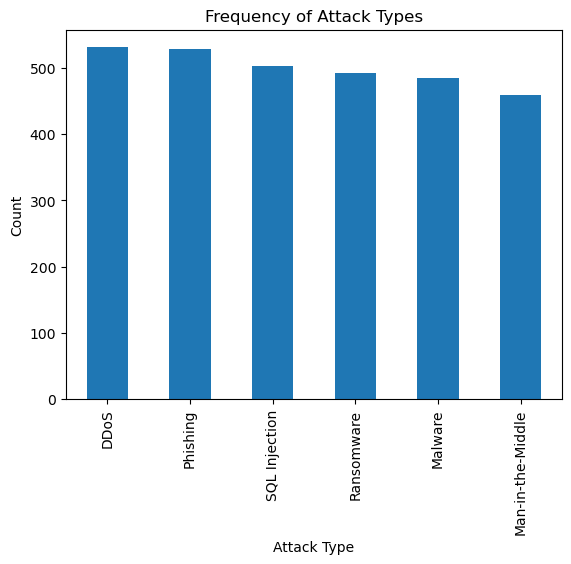

In [18]:
attack_counts.plot(kind='bar')
plt.title("Frequency of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.show()

In [19]:
attack_by_year = df['Year'].value_counts().sort_index()

In [20]:
print (attack_by_year)

Year
2015    277
2016    285
2017    319
2018    310
2019    263
2020    315
2021    299
2022    318
2023    315
2024    299
Name: count, dtype: int64


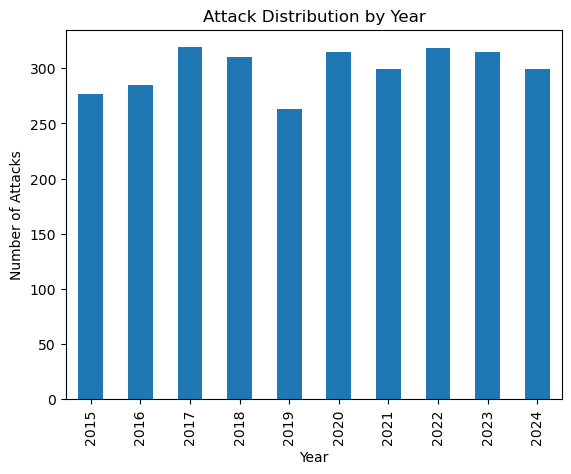

In [21]:
attack_by_year.plot(kind='bar')
plt.title("Attack Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.show()

In [22]:
attack_by_country = df['Country'].value_counts() #attack by country
print(attack_by_country)

Country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64


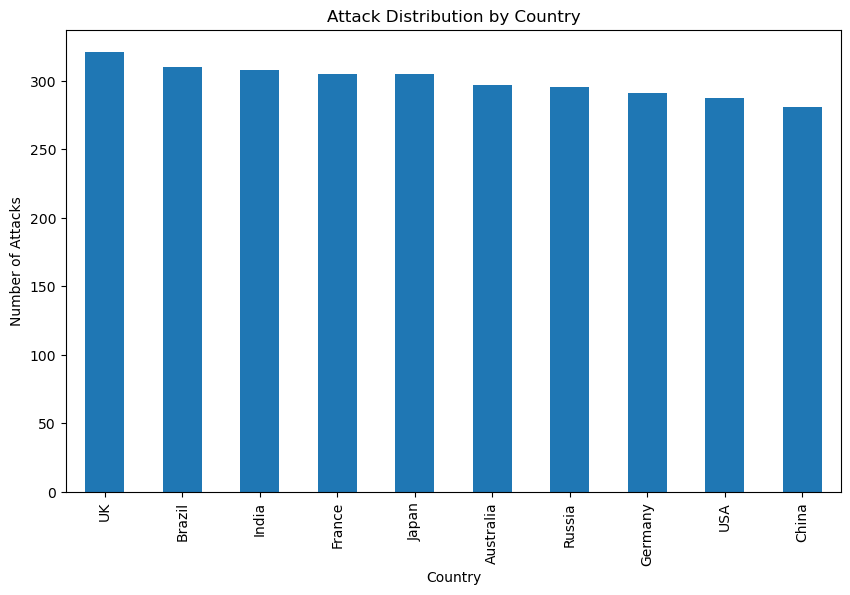

In [23]:
attack_by_country.plot(kind='bar', figsize=(10,6))
plt.title("Attack Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Attacks")
plt.show()

In [24]:
attack_by_industry = df['Target Industry'].value_counts() #count frequency of industries

In [25]:
print("Most common attack by industry:", attack_by_industry.idxmax()) #most common industry attack

Most common attack by industry: IT


In [26]:
print("Number of occurrences:", attack_by_industry.max())

Number of occurrences: 478


In [27]:
print(attack_by_industry)

Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Telecommunications    403
Government            403
Name: count, dtype: int64


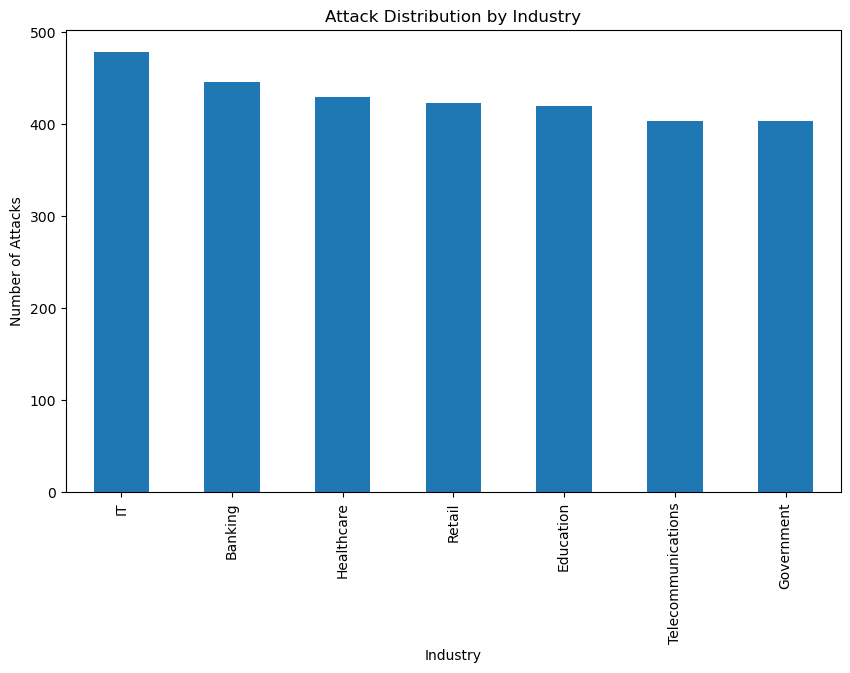

In [28]:
attack_by_industry.plot(kind='bar', figsize=(10,6))
plt.title("Attack Distribution by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Attacks")
plt.show()

In [29]:
loss_by_industry = df.groupby('Target Industry')['Financial Loss (in Million $)'].sum() #group by industry&sum finicial loss

In [30]:
loss_by_industry = loss_by_industry.sort_values(ascending=False) # sort by descending to see which industry lost the most

In [31]:
print("Industries with greatest financial loss:")
print(loss_by_industry.head())

Industries with greatest financial loss:
Target Industry
IT            24809.83
Banking       22772.39
Government    21205.33
Retail        21119.55
Healthcare    21041.29
Name: Financial Loss (in Million $), dtype: float64


In [32]:
users_by_industry = df.groupby('Target Industry')['Number of Affected Users'].sum() #group by industry&affectedusers

In [33]:
users_by_industry = users_by_industry.sort_values(ascending=False) #sorted descending

In [34]:
print("Industries with most affected users:")
print(users_by_industry.head())

Industries with most affected users:
Target Industry
IT            250094829
Banking       225098406
Healthcare    216271916
Education     215004732
Retail        206776386
Name: Number of Affected Users, dtype: int64


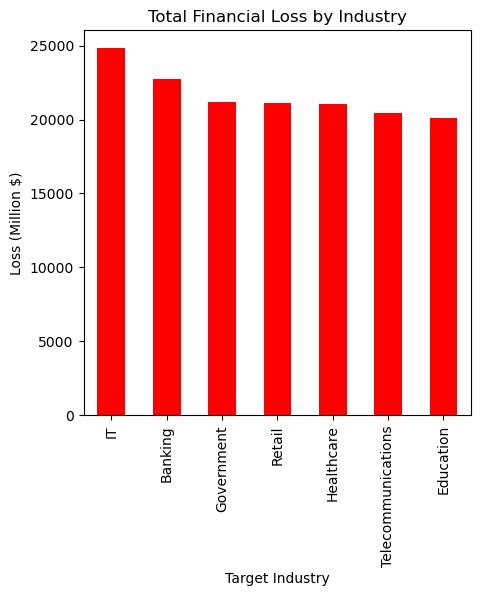

In [35]:
#Bar for finicial loss
loss_by_industry.plot(kind='bar', figsize=(5,5), color='red')
plt.title("Total Financial Loss by Industry")
plt.ylabel("Loss (Million $)")
plt.show()

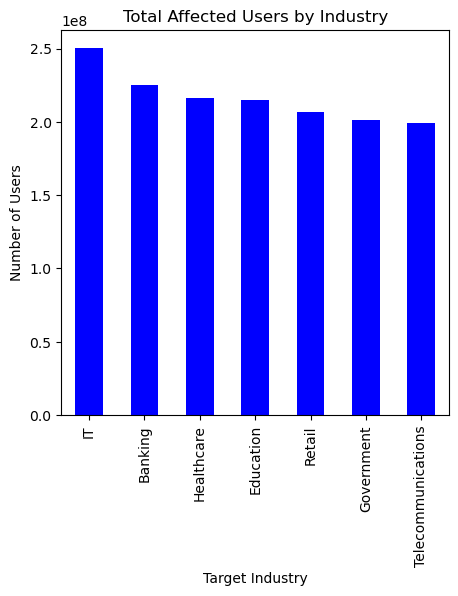

In [36]:
#Bar of affected users
users_by_industry.plot(kind='bar', figsize=(5,5), color='blue')
plt.title("Total Affected Users by Industry")
plt.ylabel("Number of Users")
plt.show()

In [37]:
# Total all financial losses
total_loss = df['Financial Loss (in Million $)'].sum()

print("Total financial loss (Million $):", total_loss)

Total financial loss (Million $): 151478.91


In [38]:
# attack type and calculate average loss
avg_loss_by_attack = df.groupby('Attack Type')['Financial Loss (in Million $)'].mean()

print("Average financial loss per attack type:")
print(avg_loss_by_attack.sort_values(ascending=False))

Average financial loss per attack type:
Attack Type
DDoS                 52.035631
Man-in-the-Middle    51.309085
Phishing             50.459905
SQL Injection        50.013042
Ransomware           49.653793
Malware              49.418454
Name: Financial Loss (in Million $), dtype: float64


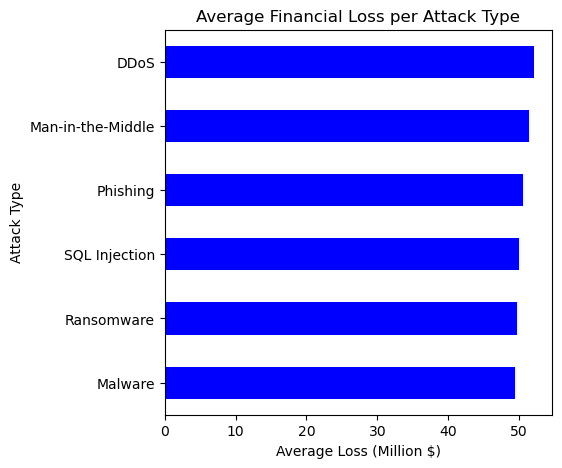

In [39]:
avg_loss_by_attack.sort_values().plot(kind='barh', figsize=(5,5), color='blue')
plt.title("Average Financial Loss per Attack Type")
plt.xlabel("Average Loss (Million $)")
plt.ylabel("Attack Type")
plt.show()

In [40]:
# Grouped country and sum financial loss
loss_by_country = df.groupby('Country')['Financial Loss (in Million $)'].sum()
# Sorted Top countries 
loss_by_country = loss_by_country.sort_values(ascending=False)

print("Financial loss by country:")
print(loss_by_country.head())

Financial loss by country:
Country
UK           16502.99
Germany      15793.24
Brazil       15782.62
Australia    15403.00
Japan        15197.34
Name: Financial Loss (in Million $), dtype: float64


In [41]:
# Group by industry&sum financial loss
loss_by_industry = df.groupby('Target Industry')['Financial Loss (in Million $)'].sum()

# Sort descending to see top industries
loss_by_industry = loss_by_industry.sort_values(ascending=False)

print("Financial loss by industry:")
print(loss_by_industry.head())


Financial loss by industry:
Target Industry
IT            24809.83
Banking       22772.39
Government    21205.33
Retail        21119.55
Healthcare    21041.29
Name: Financial Loss (in Million $), dtype: float64


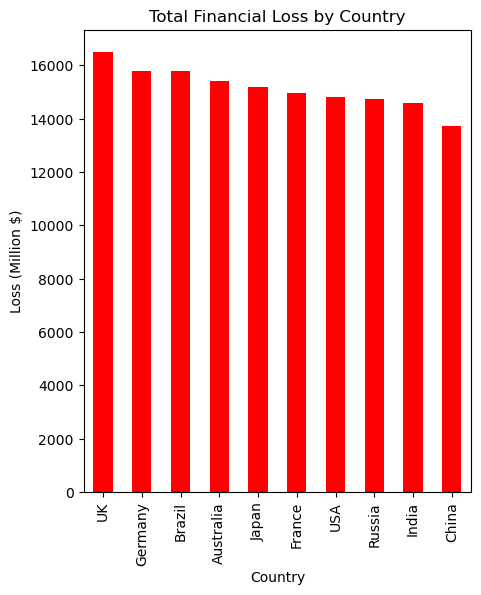

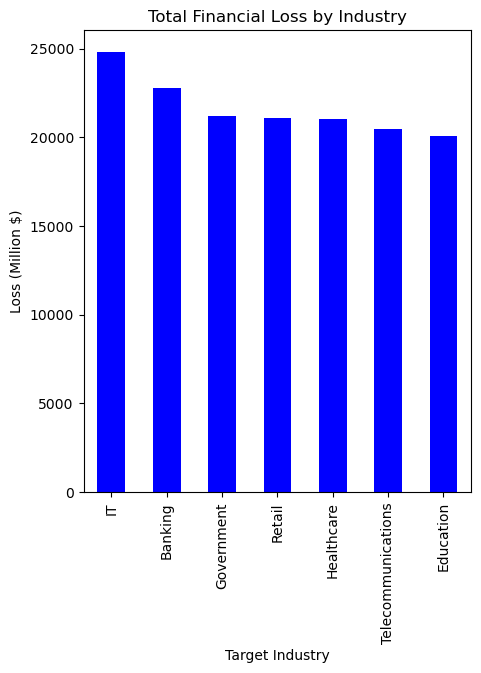

In [42]:
# Country losses
loss_by_country.plot(kind='bar', figsize=(5,6), color='red')
plt.title("Total Financial Loss by Country")
plt.ylabel("Loss (Million $)")
plt.show()

# Industry losses
loss_by_industry.plot(kind='bar', figsize=(5,6), color='blue')
plt.title("Total Financial Loss by Industry")
plt.ylabel("Loss (Million $)")
plt.show()


In [43]:
#Summary Table of Losses
#Total Financial Loss
total_loss = df['Financial Loss (in Million $)'].sum()
print("Total Financial Loss (Million $):", total_loss)

#Loss by Attack Type
loss_by_attack = df.groupby('Attack Type')['Financial Loss (in Million $)'].agg(
    Total_Loss='sum',
    Average_Loss='mean',
    Count='count'
).sort_values(by='Total_Loss', ascending=False)
print("\nLoss by Attack Type:\n", loss_by_attack)

#Loss by Industry
loss_by_industry = df.groupby('Target Industry')['Financial Loss (in Million $)'].agg(
    Total_Loss='sum',
    Average_Loss='mean',
    Count='count'
).sort_values(by='Total_Loss', ascending=False)
print("\nLoss by Industry:\n", loss_by_industry)

#Loss by Country
loss_by_country = df.groupby('Country')['Financial Loss (in Million $)'].agg(
    Total_Loss='sum',
    Average_Loss='mean',
    Count='count'
).sort_values(by='Total_Loss', ascending=False)
print("\nLoss by Country:\n", loss_by_country)

#Create a neat summary table (example: by attack type)
summary_table = loss_by_attack.reset_index()
print("\nSummary Table of Losses by Attack Type:\n", summary_table)

Total Financial Loss (Million $): 151478.91

Loss by Attack Type:
                    Total_Loss  Average_Loss  Count
Attack Type                                       
DDoS                 27630.92     52.035631    531
Phishing             26693.29     50.459905    529
SQL Injection        25156.56     50.013042    503
Ransomware           24479.32     49.653793    493
Malware              23967.95     49.418454    485
Man-in-the-Middle    23550.87     51.309085    459

Loss by Industry:
                     Total_Loss  Average_Loss  Count
Target Industry                                    
IT                    24809.83     51.903410    478
Banking               22772.39     51.173910    445
Government            21205.33     52.618685    403
Retail                21119.55     49.928014    423
Healthcare            21041.29     49.047296    429
Telecommunications    20459.09     50.766973    403
Education             20071.43     47.903174    419

Loss by Country:
            Total_L

In [44]:
#Total of affected users
total_users = df['Number of Affected Users'].sum()
print("Total affected users:", total_users)

Total affected users: 1514052409


In [45]:
#Grouped attack type & affected users
avg_users_by_attack = df.groupby('Attack Type')['Number of Affected Users'].mean()

print("Average affected users per attack type:")
print(avg_users_by_attack.sort_values(ascending=False))

Average affected users per attack type:
Attack Type
Man-in-the-Middle    520064.320261
SQL Injection        512469.833002
Malware              508780.232990
Ransomware           502825.369168
DDoS                 499437.410546
Phishing             487179.536862
Name: Number of Affected Users, dtype: float64


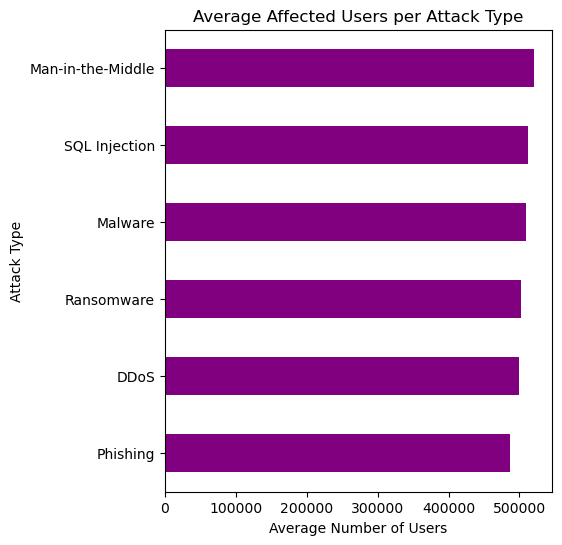

In [46]:
avg_users_by_attack.sort_values().plot(kind='barh', figsize=(5,6), color='purple')
plt.title("Average Affected Users per Attack Type")
plt.xlabel("Average Number of Users")
plt.ylabel("Attack Type")
plt.show()

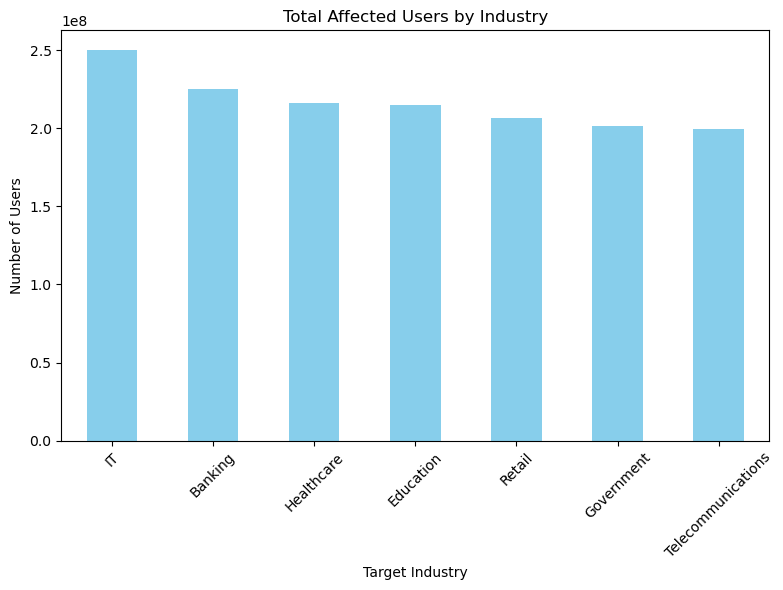

In [47]:
# Total Affected Users by Industry
users_by_industry = df.groupby('Target Industry')['Number of Affected Users'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
users_by_industry.plot(kind='bar', color='skyblue')
plt.title("Total Affected Users by Industry")
plt.xlabel("Target Industry")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
#highest affected users with attack type
most_damaging_attack = avg_users_by_attack.idxmax()
max_avg_users = avg_users_by_attack.max()

print("Most damaging attack type by user impact:", most_damaging_attack)
print("Average users affected:", max_avg_users)

Most damaging attack type by user impact: Man-in-the-Middle
Average users affected: 520064.3202614379


In [49]:
#Most Exploited Vulnerabilities
vuln_counts = df['Security Vulnerability Type'].value_counts()
print("Most exploited vulnerability:", vuln_counts.idxmax())
print("Number of occurrences:", vuln_counts.max())
print(vuln_counts)

Most exploited vulnerability: Zero-day
Number of occurrences: 785
Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: count, dtype: int64


In [50]:
# grouped attack type&vulnerability type
vuln_by_attack = df.groupby(['Attack Type', 'Security Vulnerability Type']).size()

print("Vulnerabilities by attack type:")
print(vuln_by_attack)

Vulnerabilities by attack type:
Attack Type        Security Vulnerability Type
DDoS               Social Engineering             132
                   Unpatched Software             127
                   Weak Passwords                 146
                   Zero-day                       126
Malware            Social Engineering             130
                   Unpatched Software             107
                   Weak Passwords                 113
                   Zero-day                       135
Man-in-the-Middle  Social Engineering             104
                   Unpatched Software             135
                   Weak Passwords                 102
                   Zero-day                       118
Phishing           Social Engineering             124
                   Unpatched Software             121
                   Weak Passwords                 124
                   Zero-day                       160
Ransomware         Social Engineering             141
   

In [51]:
#Vulnerabilities by Attack Type - Table
vuln_by_attack = df.groupby(['Attack Type', 'Security Vulnerability Type']).size().unstack(fill_value=0)
print("\nVulnerabilities by Attack Type:\n")
print(vuln_by_attack)


Vulnerabilities by Attack Type:

Security Vulnerability Type  Social Engineering  Unpatched Software  \
Attack Type                                                           
DDoS                                        132                 127   
Malware                                     130                 107   
Man-in-the-Middle                           104                 135   
Phishing                                    124                 121   
Ransomware                                  141                 124   
SQL Injection                               116                 124   

Security Vulnerability Type  Weak Passwords  Zero-day  
Attack Type                                            
DDoS                                    146       126  
Malware                                 113       135  
Man-in-the-Middle                       102       118  
Phishing                                124       160  
Ransomware                              116       112  
SQL I

In [52]:
# Grouped industry&vulnerability type
vuln_by_industry = df.groupby(['Target Industry', 'Security Vulnerability Type']).size()

print("Vulnerabilities by industry:")
print(vuln_by_industry)


Vulnerabilities by industry:
Target Industry     Security Vulnerability Type
Banking             Social Engineering             117
                    Unpatched Software             107
                    Weak Passwords                 111
                    Zero-day                       110
Education           Social Engineering             115
                    Unpatched Software             101
                    Weak Passwords                  94
                    Zero-day                       109
Government          Social Engineering              96
                    Unpatched Software              97
                    Weak Passwords                  98
                    Zero-day                       112
Healthcare          Social Engineering             112
                    Unpatched Software             105
                    Weak Passwords                 115
                    Zero-day                        97
IT                  Social Engineering     

In [53]:
#Vulnerabilities by Industry -Table
vuln_by_industry = df.groupby(['Target Industry', 'Security Vulnerability Type']).size().unstack(fill_value=0)
print("\nVulnerabilities by Industry:\n")
print(vuln_by_industry)


Vulnerabilities by Industry:

Security Vulnerability Type  Social Engineering  Unpatched Software  \
Target Industry                                                       
Banking                                     117                 107   
Education                                   115                 101   
Government                                   96                  97   
Healthcare                                  112                 105   
IT                                          107                 112   
Retail                                       97                 109   
Telecommunications                          103                 107   

Security Vulnerability Type  Weak Passwords  Zero-day  
Target Industry                                        
Banking                                 111       110  
Education                                94       109  
Government                               98       112  
Healthcare                              115      

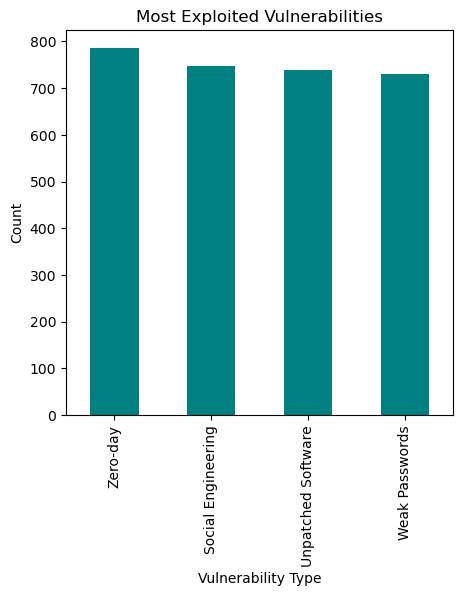

In [54]:
# Top vulnerabilities overall
vuln_counts.plot(kind='bar', figsize=(5,5), color='teal')
plt.title("Most Exploited Vulnerabilities")
plt.xlabel("Vulnerability Type")
plt.ylabel("Count")
plt.show()

In [55]:
#Incidents by attack source
incidents_by_source = df['Attack Source'].value_counts()
print("Incidents by attack source:")
print(incidents_by_source)

Incidents by attack source:
Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64


In [56]:
#Financial loss by Attack Source
loss_by_source = df.groupby('Attack Source')['Financial Loss (in Million $)'].sum()
loss_by_source = loss_by_source.sort_values(ascending=False)
print("Financial loss by attack source:")
print(loss_by_source)

Financial loss by attack source:
Attack Source
Nation-state    40497.22
Unknown         38810.61
Insider         36673.51
Hacker Group    35497.57
Name: Financial Loss (in Million $), dtype: float64


In [57]:
#Incident resolution time by Attack Source
resolution_by_source = df.groupby('Attack Source')['Incident Resolution Time (in Hours)'].mean()
print("Average resolution time by attack source:")
print(resolution_by_source.sort_values(ascending=False))

Average resolution time by attack source:
Attack Source
Hacker Group    37.212828
Insider         36.351064
Nation-state    36.329975
Unknown         36.091146
Name: Incident Resolution Time (in Hours), dtype: float64


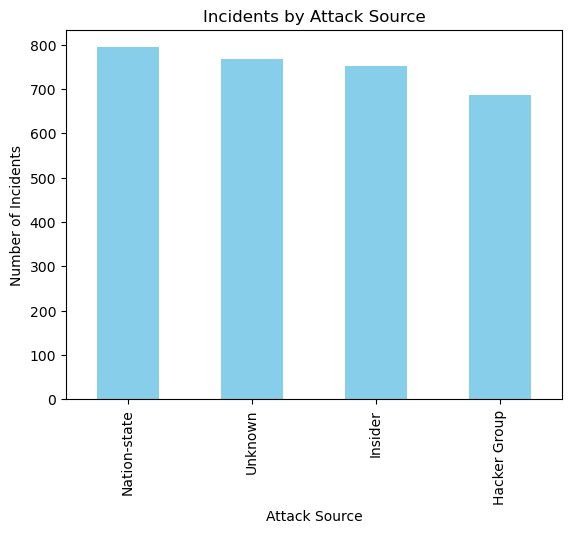

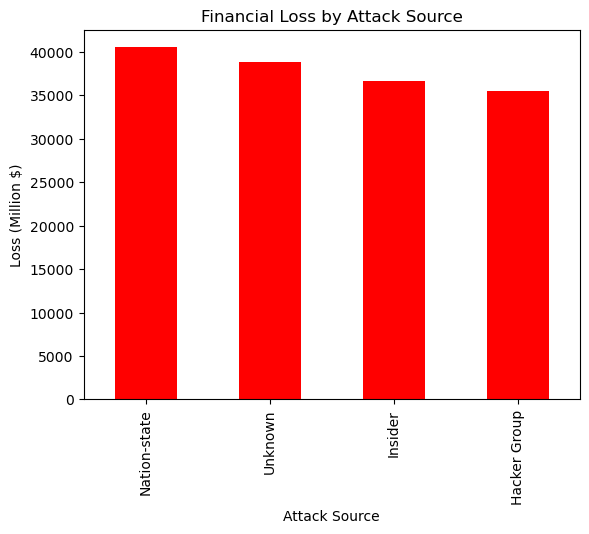

C:\Users\User\AppData\Local\Temp\ipykernel_7804\103860599.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


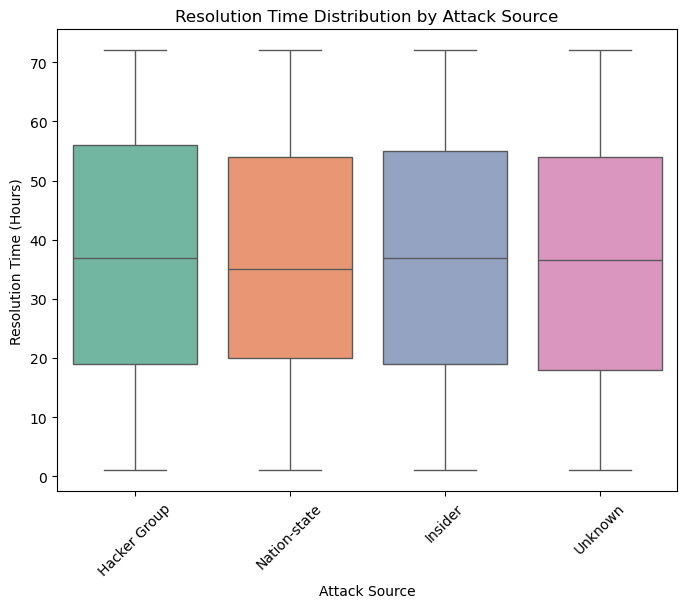

In [58]:
# Incidents
incidents_by_source.plot(kind='bar', color='skyblue')
plt.title("Incidents by Attack Source")
plt.ylabel("Number of Incidents")
plt.show()

# Financial loss
loss_by_source.plot(kind='bar', color='red')
plt.title("Financial Loss by Attack Source")
plt.ylabel("Loss (Million $)")
plt.show()

#Resolution time
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="Attack Source",
    y="Incident Resolution Time (in Hours)",   
    palette="Set2"
)

plt.title("Resolution Time Distribution by Attack Source")
plt.ylabel("Resolution Time (Hours)")
plt.xlabel("Attack Source")
plt.xticks(rotation=45)
plt.show()

In [59]:
#Which Defense Mechanisms Are Used Most
defense_counts = df['Defense Mechanism Used'].value_counts()

In [60]:
print("Most used defense mechanism:", defense_counts.idxmax())
print("Number of times used:", defense_counts.max())

Most used defense mechanism: Antivirus
Number of times used: 628


In [61]:
print(defense_counts)

Defense Mechanism Used
Antivirus             628
VPN                   612
Encryption            592
Firewall              585
AI-based Detection    583
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_7804\1688373275.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=defense_counts.index, y=defense_counts.values, palette="Blues_d")


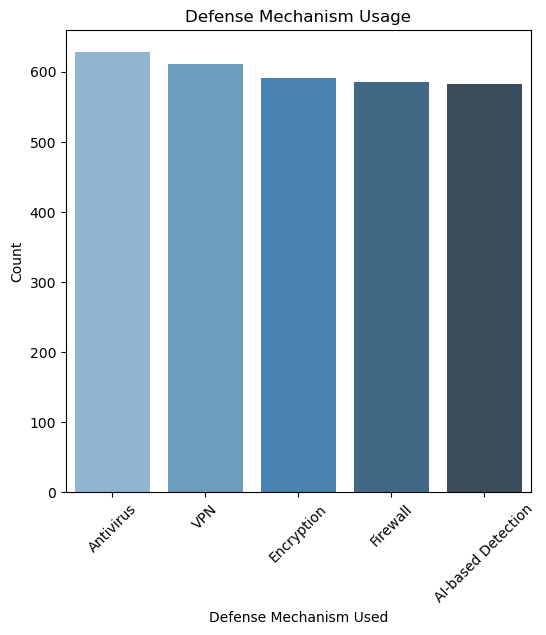

In [69]:
#Defense mechanism usage counts
defense_counts = df['Defense Mechanism Used'].value_counts()
plt.figure(figsize=(6,6))
sns.barplot(x=defense_counts.index, y=defense_counts.values, palette="Blues_d")
plt.title("Defense Mechanism Usage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [62]:
#Incident Resolution Time by Defense Mechanism
avg_resolution_by_defense = df.groupby('Defense Mechanism Used')['Incident Resolution Time (in Hours)'].mean()
print("Average resolution time by defense mechanism:")
print(avg_resolution_by_defense.sort_values(ascending=False))

Average resolution time by defense mechanism:
Defense Mechanism Used
VPN                   36.864379
AI-based Detection    36.612350
Encryption            36.589527
Antivirus             36.573248
Firewall              35.714530
Name: Incident Resolution Time (in Hours), dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_7804\3921560201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


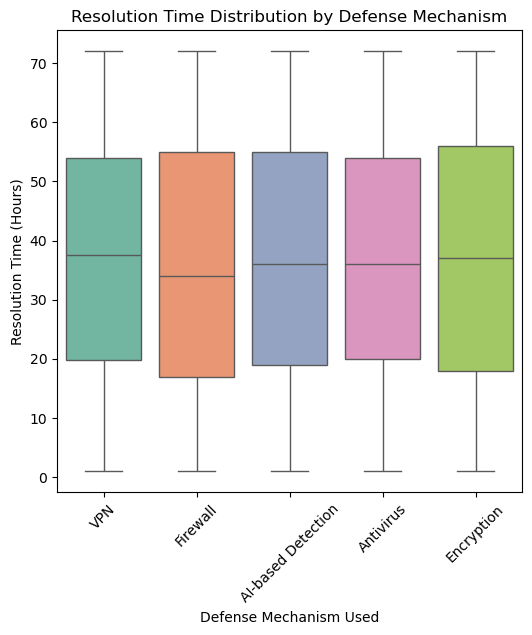

In [70]:
plt.figure(figsize=(6,6))
sns.boxplot(
    data=df,
    x="Defense Mechanism Used",
    y="Incident Resolution Time (in Hours)",
    palette="Set2"
)
plt.title("Resolution Time Distribution by Defense Mechanism")
plt.ylabel("Resolution Time (Hours)")
plt.xticks(rotation=45)
plt.show()

In [63]:
#Financial Loss by Defense Mechanism
loss_by_defense = df.groupby('Defense Mechanism Used')['Financial Loss (in Million $)'].sum()
print("Financial loss by defense mechanism:")
print(loss_by_defense.sort_values(ascending=False))

Financial loss by defense mechanism:
Defense Mechanism Used
Antivirus             32466.87
VPN                   30728.32
Encryption            29836.92
AI-based Detection    29360.77
Firewall              29086.03
Name: Financial Loss (in Million $), dtype: float64


In [64]:
#Resolution Time (Overall)
avg_resolution = df['Incident Resolution Time (in Hours)'].mean()
print("Average resolution time (hours):", avg_resolution)

Average resolution time (hours): 36.476


In [65]:
#ResolutionTime by Attack Type
resolution_by_attack = df.groupby('Attack Type')['Incident Resolution Time (in Hours)'].mean()

print("Average resolution time by attack type:")
print(resolution_by_attack.sort_values(ascending=False))

Average resolution time by attack type:
Attack Type
Malware              37.074227
SQL Injection        36.906561
Man-in-the-Middle    36.871460
Ransomware           36.533469
Phishing             35.913043
DDoS                 35.687382
Name: Incident Resolution Time (in Hours), dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_7804\4018252674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


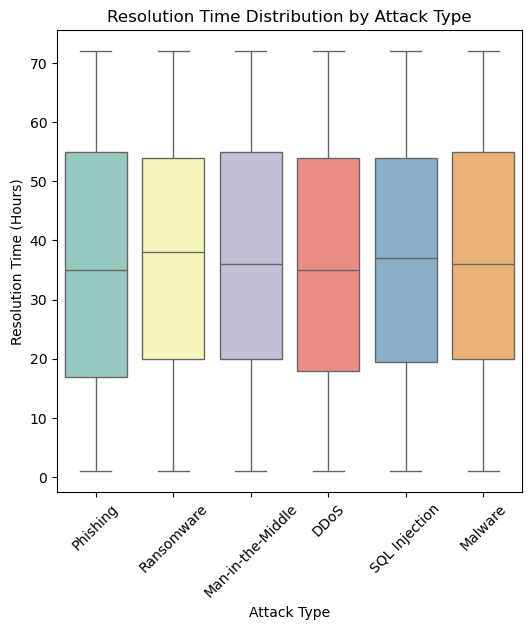

In [71]:
plt.figure(figsize=(6,6))
sns.boxplot(
    data=df,
    x="Attack Type",
    y="Incident Resolution Time (in Hours)",
    palette="Set3"
)
plt.title("Resolution Time Distribution by Attack Type")
plt.ylabel("Resolution Time (Hours)")
plt.xticks(rotation=45)
plt.show()


In [66]:
#ResolutionTime byIndustry
resolution_by_industry = df.groupby('Target Industry')['Incident Resolution Time (in Hours)'].mean()

print("Average resolution time by industry:")
print(resolution_by_industry.sort_values(ascending=False))

#ResolutionTime byCountry
resolution_by_country = df.groupby('Country')['Incident Resolution Time (in Hours)'].mean()

print("Average resolution time by country:")
print(resolution_by_country.sort_values(ascending=False))

Average resolution time by industry:
Target Industry
Government            37.593052
Retail                37.219858
Telecommunications    37.062035
IT                    36.169456
Education             35.906921
Healthcare            35.806527
Banking               35.737079
Name: Incident Resolution Time (in Hours), dtype: float64
Average resolution time by country:
Country
Brazil       37.761290
China        37.398577
Japan        37.098361
UK           36.925234
Australia    36.481481
France       36.216393
Germany      36.017182
India        35.931818
Russia       35.535593
USA          35.306620
Name: Incident Resolution Time (in Hours), dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_7804\760255563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


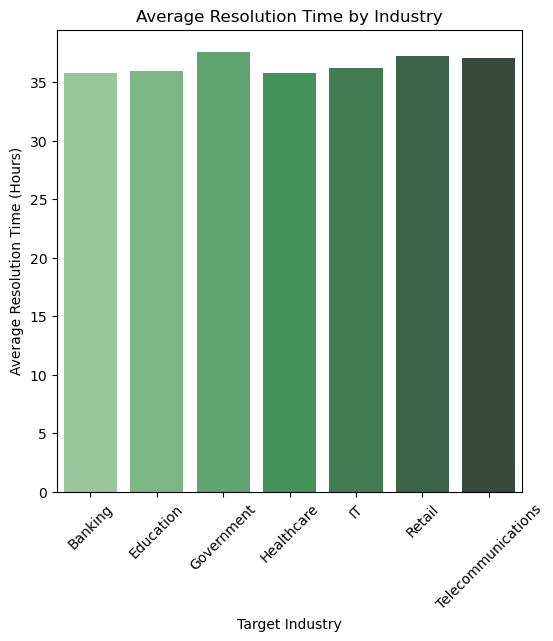

In [72]:
resolution_by_industry = df.groupby('Target Industry')["Incident Resolution Time (in Hours)"].mean().reset_index()

plt.figure(figsize=(6,6))
sns.barplot(
    data=resolution_by_industry,
    x="Target Industry",
    y="Incident Resolution Time (in Hours)",
    palette="Greens_d"
)
plt.title("Average Resolution Time by Industry")
plt.ylabel("Average Resolution Time (Hours)")
plt.xticks(rotation=45)
plt.show()


In [63]:
#Trend Analysis (2015-2024)
df.groupby("Year")["Financial Loss (in Million $)"].sum().reset_index() #Group by year&sum financial losses
df.groupby("Year")["Incident Resolution Time (in Hours)"].mean().reset_index() # Group by year&average resolution time.
df.groupby(["Year","Attack Type"]).size().reset_index(name="count") #Group by peryear&attack types
df.groupby(["Year","Security Vulnerability Type"]).size().reset_index(name="count") #Group by vulnerabilities per year.


,Year,Security Vulnerability Type,count
0,2015,Social Engineering,68
1,2015,Unpatched Software,71
2,2015,Weak Passwords,53
3,2015,Zero-day,85
4,2016,Social Engineering,79
5,2016,Unpatched Software,72
6,2016,Weak Passwords,73
7,2016,Zero-day,61
8,2017,Social Engineering,74
9,2017,Unpatched Software,75


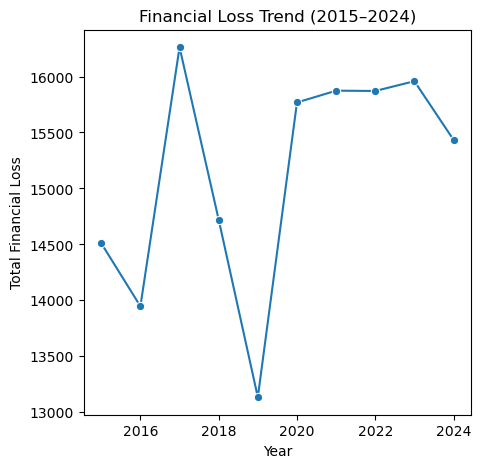

In [67]:
#Financial Loss Trend

loss_trend = df.groupby("Year")["Financial Loss (in Million $)"].sum().reset_index()

plt.figure(figsize=(5,5))
sns.lineplot(data=loss_trend, x="Year", y="Financial Loss (in Million $)", marker="o")
plt.title("Financial Loss Trend (2015–2024)")
plt.ylabel("Total Financial Loss")
plt.show()


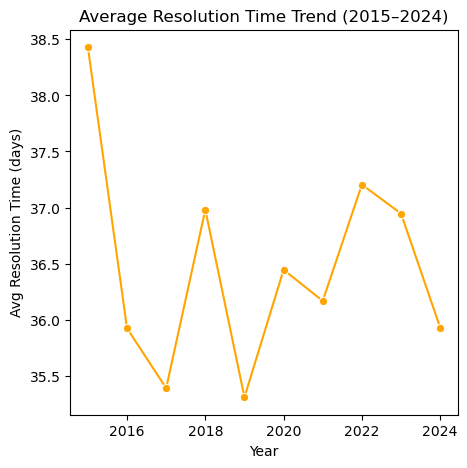

In [69]:
#Resolution Time Trend
resolution_trend = df.groupby("Year")["Incident Resolution Time (in Hours)"].mean().reset_index()

plt.figure(figsize=(5,5))
sns.lineplot(data=resolution_trend, x="Year", y="Incident Resolution Time (in Hours)", marker="o", color="orange")
plt.title("Average Resolution Time Trend (2015–2024)")
plt.ylabel("Avg Resolution Time (days)")
plt.show()

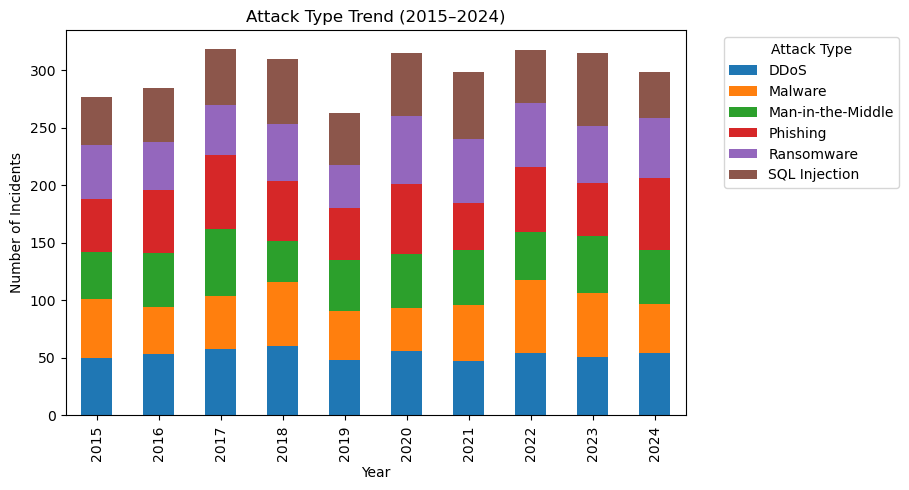

In [72]:
#Attack Type Trend
attack_trend = df.groupby(["Year","Attack Type"]).size().reset_index(name="count")
attack_pivot = attack_trend.pivot(index="Year", columns="Attack Type", values="count").fillna(0)

attack_pivot.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Attack Type Trend (2015–2024)")
plt.ylabel("Number of Incidents")
plt.legend(title="Attack Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

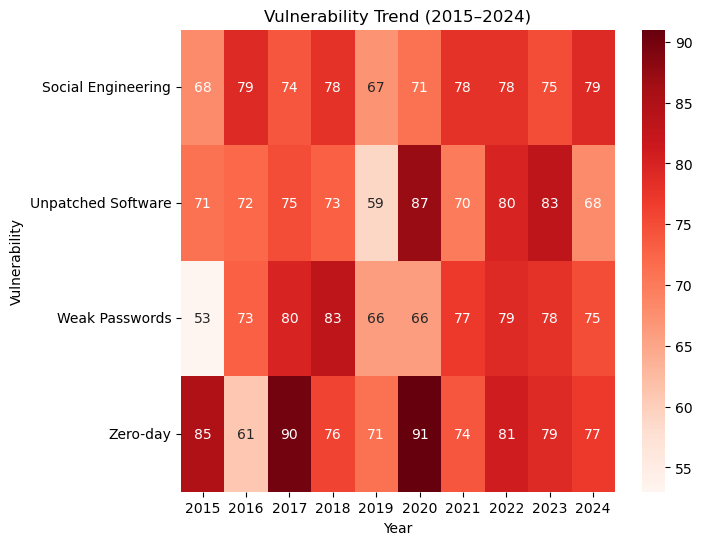

In [76]:
#Vulnerability Trend
vuln_trend = df.groupby(["Year","Security Vulnerability Type"]).size().reset_index(name="count")
vuln_pivot = vuln_trend.pivot(index="Security Vulnerability Type", columns="Year", values="count").fillna(0)

plt.figure(figsize=(7,6))
sns.heatmap(vuln_pivot, cmap="Reds", annot=True, fmt="d")
plt.title("Vulnerability Trend (2015–2024)")
plt.ylabel("Vulnerability")
plt.xlabel("Year")
plt.show()

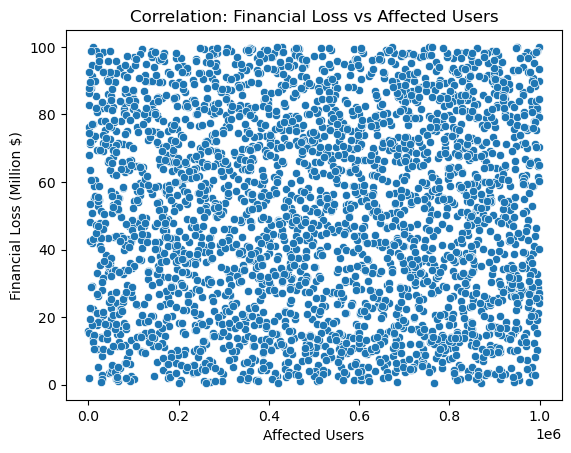

Correlation (Financial Loss vs Affected Users): 0.0017867355720258382


In [58]:
#Financial Loss vs Affected Users

sns.scatterplot(x='Number of Affected Users', 
                y='Financial Loss (in Million $)', 
                data=df)

plt.title("Correlation: Financial Loss vs Affected Users")
plt.xlabel("Affected Users")
plt.ylabel("Financial Loss (Million $)")
plt.show()

# Correlation coefficient
corr1 = df['Number of Affected Users'].corr(df['Financial Loss (in Million $)'])
print("Correlation (Financial Loss vs Affected Users):", corr1)

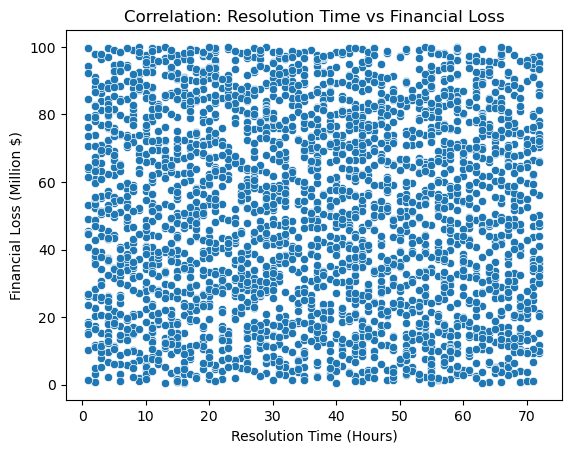

Correlation (Resolution Time vs Financial Loss): -0.012670791107337322


In [59]:
#Resolution Time vs Financial Loss

sns.scatterplot(x='Incident Resolution Time (in Hours)', 
                y='Financial Loss (in Million $)', 
                data=df)

plt.title("Correlation: Resolution Time vs Financial Loss")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Financial Loss (Million $)")
plt.show()

corr2 = df['Incident Resolution Time (in Hours)'].corr(df['Financial Loss (in Million $)'])
print("Correlation (Resolution Time vs Financial Loss):", corr2)

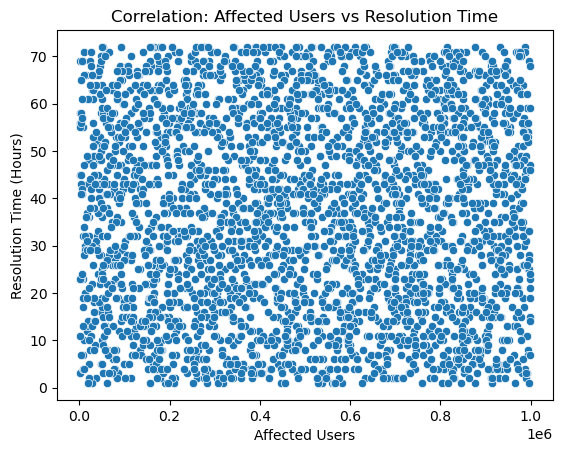

Correlation (Affected Users vs Resolution Time): 0.0058931729919502835


In [60]:
#Affected Users vs Resolution Time

sns.scatterplot(x='Number of Affected Users', 
                y='Incident Resolution Time (in Hours)', 
                data=df)

plt.title("Correlation: Affected Users vs Resolution Time")
plt.xlabel("Affected Users")
plt.ylabel("Resolution Time (Hours)")
plt.show()

corr3 = df['Number of Affected Users'].corr(df['Incident Resolution Time (in Hours)'])
print("Correlation (Affected Users vs Resolution Time):", corr3)